In [1]:
from IPython.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
<div class="usecase-title">Optimisation of Outdoor Fitness Activities in Melbourne</div>
</div>

<div class="usecase-details">
<b>Author:</b> Ananya Krishnan<br>
<b>Created:</b> T1, 2025<br>
<b>Updated:</b> T2, 2026 (Rupanshi)<br>
<b>Time to Complete:</b> 90 mins<br>
<b>Level:</b> Intermediate<br>
<b>Pre-requisite Skills:</b> Python, Pandas, GeoPandas, and basic geospatial analysis concepts
</div>

<div class="usecase-unnumbered-heading"><b>Scenario</b></div>


<div class="usecase-body">
A City of Melbourne recreation or urban-planning team wants to understand which pedestrian locations already provide convenient access to outdoor fitness opportunities and which locations may benefit from additional support. The team needs a simple, evidence-based way to compare access to open spaces, public amenities and tree canopy so that planning decisions can better support residents, workers and visitors who use the city for walking, exercise and other outdoor activity.
</div>


<div class="usecase-unnumbered-heading"><b>What this usecase will teach you</b></div>


<div class="usecase-body">
This use case demonstrates how multiple public datasets can be combined to assess the accessibility of outdoor fitness environments and produce evidence-based spatial insights.
<div class="usecase-list">
<ul>
<li>Retrieve and inspect datasets from the Melbourne Open Data API.</li>
<li>Clean, transform and combine datasets for geospatial analysis.</li>
<li>Calculate nearest-feature distances using a projected coordinate system.</li>
<li>Develop accessibility scores and categories from spatial measurements.</li>
<li>Visualise and interpret accessibility results using charts and maps.</li>
</ul>
</div>
</div>


<div class="usecase-unnumbered-heading"><b>Background</b></div>


<div class="usecase-body">
The City of Melbourne provides numerous parks, playgrounds, walking tracks and open spaces that encourage outdoor fitness activities. Choosing suitable locations for exercise can depend on pedestrian activity, accessibility, tree canopy coverage and the availability of amenities such as drinking fountains, seating and public toilets. Outdoor fitness spaces can better support healthy and active lifestyles when these features are conveniently accessible.

This analysis combines pedestrian locations with information about parks, playgrounds, pedestrian networks, public amenities and tree canopy. Geospatial preprocessing and nearest-feature distance calculations are used to create component accessibility scores, which are then combined into an overall MOP Accessibility Score to identify locations with high, moderate or low accessibility.
</div>


<div class="usecase-unnumbered-heading"><b>Data Sets</b></div>


<div class="usecase-body">
These datasets provide the pedestrian, open-space, amenity and environmental information required to calculate and interpret outdoor fitness accessibility.

<div class="usecase-datasets">
<ul>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-sensor-locations/">Pedestrian Counting System - Sensor Locations</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-past-hour-counts-per-minute/">Pedestrian Counting System - Past Hour (counts per minute)</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/trees-with-species-and-dimensions-urban-forest/">Trees, with species and dimensions (Urban Forest)</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/playgrounds/">Playgrounds</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-network/">Pedestrian Network</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/drinking-fountains/">Drinking fountains</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/public-toilets/">Public toilets</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/street-furniture-including-bollards-bicycle-rails-bins-drinking-fountains-horse-/">Street furniture including bollards, bicycle rails, bins, drinking fountains, horse troughs, planter boxes, seats, barbecues</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/tree-canopies-public-realm-2018-urban-forest/">Tree canopies public realm 2018 (Urban Forest)</a></li>
</ul>
</div>
</div>


<div class="usecase-unnumbered-heading"><b>Contents</b></div>


<div class="usecase-contents">
<a href="#section-1">1. Import Required Libraries</a><br>
<a href="#section-2">2. Data Acquisition</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-2-1">2.1 Explore the Datasets</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-2-2">2.2 Understand the Dataset Structure</a><br>

<a href="#section-3">3. Data Cleaning and Pre-processing</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-3-1">3.1 Cleaning Individual Datasets</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-3-2">3.2 Extracting Geographic Coordinates</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-3-3">3.3 Geospatial Data Processing</a><br>

<a href="#section-4">4. Geospatial Accessibility Analysis</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-1">4.1 Convert Geospatial Data to a Projected CRS</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-2">4.2 Open-Space Accessibility</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-3">4.3 Public Amenity Accessibility</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-4">4.4 Tree-Canopy Accessibility</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-5">4.5 Accessibility Scoring</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-6">4.6 Overall MOP Accessibility</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-7">4.7 Visualisation of Accessibility Results</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-7-1">4.7.1 Average Distance Comparison</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-7-2">4.7.2 Distribution of Accessibility Distances</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-7-3">4.7.3 Final Accessibility Categories</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-4-8">4.8 Final MOP Accessibility Map</a><br>

<a href="#section-5">5. Results and Findings</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-5-1">5.1 Overall MOP Accessibility</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-5-2">5.2 Accessibility to Open Spaces</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-5-3">5.3 Accessibility to Public Amenities</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;<a href="#section-5-4">5.4 Accessibility to Tree Canopy</a>
</div>

<a id="section-1"></a>
<div id="section-1" class="usecase-section-heading">
1. Import Required Libraries
</div>

In [2]:
%pip install requests pandas numpy geopandas matplotlib

import requests
import pandas as pd
from io import StringIO
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

<a id="section-2"></a>
<div id="section-2" class="usecase-section-heading"><b>2. Data Acquisition</b></div>


<div class="usecase-body">
Multiple datasets are retrieved from the Melbourne Open Data platform through its public API. A reusable function downloads each dataset in CSV format and loads it into a Pandas DataFrame so the same acquisition process can be applied consistently across the sources.
</div>


In [3]:
# parsing the dataset name and API key
def API_upload(link_dataset):

    # define API endpoints
    core_url= 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
    # dataset_id= apiKey
    key= link_dataset
    format= 'csv'
    web_url= f'{core_url}{key}/exports/{format}'
    params={
        # similar to SQL's  queries
        'select': '*',      # selects all fields from dataset
        'timezone': 'UTC',  # setting desired time zone in return data
        'lang': 'en',       # specifies language preference of data being retrieved
        'limit': '-1',      # defines maximum number of records to return
    }
    # get request for retrieving response
    response= requests.get(web_url, params= params)
    if response.status_code == 200:
        url_content= response.content.decode('utf-8')                   # convert raw response in bytes into UTF-8 encoded string
        df_dataset= pd.read_csv(StringIO(url_content), delimiter= ';')  # parse the csv content into a pandas DataFrame
        print('\n', key, '\n', df_dataset)
        pd.set_option('display.max_columns', None)                      # exhibit all coloumns of the data set
        print('\nlength of above dataset=', len(df_dataset))            # length of dataset computed
        return df_dataset
    else:
        return (print(f'Error fetching data from {web_url}: {response.status_code}'))

# Pedestrian sensor locations
link_pedCount= 'pedestrian-counting-system-sensor-locations'
# Pedestrian counts per minute
link_countPm= 'pedestrian-counting-system-past-hour-counts-per-minute'
# Urban forest
link_urbanForest= 'trees-with-species-and-dimensions-urban-forest'
# Playgrounds
link_playground= 'playgrounds'
# Pedestrian network
link_pedTrack= 'pedestrian-network'
# Drinking fountains
link_drinkingFountains= 'drinking-fountains'
# Public washrooms
link_publicWashrooms= 'public-toilets'
# Public assets (including seats)
link_publicAsset= 'street-furniture-including-bollards-bicycle-rails-bins-drinking-fountains-horse-'
# Tree canopy
#link_treeCanopy= 'tree-canopies-2021-urban-forest'
link_treeCanopy= 'tree-canopies-public-realm-2018-urban-forest'

# download url 1.5 (Service 1.URL)

# loading the data via function 'API_upload()'-
# pedestrian counting system
df_pedFreq= API_upload(link_pedCount)
# pedestrian counting each minute
df_pedFreq_Pm= API_upload(link_countPm)
# urban forest in Melbourne
df_urbanForest= API_upload(link_urbanForest)
# playgrounds in Melbourne
df_playground= API_upload(link_playground)
# pedestrian network/track of Melbourne city
df_pedTrack= API_upload(link_pedTrack)
# drinking fountains in Melbourne city
df_drinkingFountains= API_upload(link_drinkingFountains)
# public washrooms in Melbourne city
df_publicWashroom= API_upload(link_publicWashrooms)
# public asset in Melbourne city
df_publicAsset= API_upload(link_publicAsset)
# tree canopies in Melbourne city
df_treeCanopy= API_upload(link_treeCanopy)








 pedestrian-counting-system-sensor-locations 
      location_id                       sensor_description sensor_name  \
0              3                        Melbourne Central    Swa295_T   
1              5                           Princes Bridge     PriNW_T   
2              9                   Southern Cross Station    Col700_T   
3             11  Docklands Waterfront City Building Side    WatCit_T   
4             12                                 New Quay      NewQ_T   
..           ...                                      ...         ...   
129          167     I-Hub 526 La Trobe Street (Crossing)    Lat526_T   
130          179             61-67 Power Street Southbank     Pow61_T   
131          182                          163 King Street   King163_T   
132          184                     124 Elizabeth Street    Eli124_T   
133          187   RMIT Building 22 - 330 Swanston Street    Swa330_T   

    installation_date                                               note  \

<a id="section-2-1"></a>
<div id="section-2-1" class="usecase-sub-section-heading"><b>2.1 Explore the Datasets</b></div>


<div class="usecase-body">
The returned records are inspected to confirm that each dataset has loaded successfully and to understand the information available before cleaning and analysis.
</div>


In [4]:
# pedestrian counting system
dataset_pedPopulation= df_pedFreq.head(len(df_pedFreq))
print('\nSensor Location Dataset:\n', dataset_pedPopulation)

# pedestrian counting each minute
dataset_pedPopulation_Pm= df_pedFreq_Pm.head(len(df_pedFreq_Pm))
print('\nPedestrian Count Per Minute Dataset:\n', dataset_pedPopulation_Pm)

# urban forest in Melbourne
dataset_urbanForest= df_urbanForest.head(len(df_urbanForest))
print('\nUrban Forest Dataset:\n', dataset_urbanForest)

# playgrounds in Melbourne
dataset_playground= df_playground.head(len(df_playground))
print('\nPlayground Dataset:\n', dataset_playground)

# pedestrian network/track of Melbourne city
dataset_pedTrack= df_pedTrack.head(len(df_pedTrack))
print('\nPedestrian Track Dataset:\n', dataset_pedTrack)

# drinking fountains in Melbourne city
dataset_drinkingFountains= df_drinkingFountains.head(len(df_drinkingFountains))
print('\nDrinking Fountains Dataset:\n', dataset_drinkingFountains)

# public washrooms in Melbourne city
dataset_publicWashroom= df_publicWashroom.head(len(df_publicWashroom))
print('\nPublic Washroom Dataset:\n', dataset_publicWashroom)

# public asset in Melbourne city
dataset_publicAsset= df_publicAsset.head(len(df_publicAsset))
print('\nPublic Assets Dataset:\n', dataset_publicAsset)

# tree canopies in Melbourne city
dataset_treeCanopy= df_treeCanopy.head(len(df_treeCanopy))
print('\nTree Canopies Dataset:\n', dataset_treeCanopy)








Sensor Location Dataset:
      location_id                       sensor_description sensor_name  \
0              3                        Melbourne Central    Swa295_T   
1              5                           Princes Bridge     PriNW_T   
2              9                   Southern Cross Station    Col700_T   
3             11  Docklands Waterfront City Building Side    WatCit_T   
4             12                                 New Quay      NewQ_T   
..           ...                                      ...         ...   
129          167     I-Hub 526 La Trobe Street (Crossing)    Lat526_T   
130          179             61-67 Power Street Southbank     Pow61_T   
131          182                          163 King Street   King163_T   
132          184                     124 Elizabeth Street    Eli124_T   
133          187   RMIT Building 22 - 330 Swanston Street    Swa330_T   

    installation_date                                               note  \
0          2009-03-2

<a id="section-2-2"></a>
<div id="section-2-2" class="usecase-sub-section-heading"><b>2.2 Understand the Dataset Structure</b></div>


<div class="usecase-body">
Columns, data types, summary statistics and missing values are reviewed to identify inconsistencies or incomplete records that could affect the geospatial analysis and to determine the preprocessing required.
</div>


In [5]:
# Function to display summary information for a dataset
def explore_dataset(dataset, dataset_name):
    print("=" * 60)
    print(f"{dataset_name}")
    print("=" * 60)

    print("\nDataset Information:")
    dataset.info()

    print("\nDescriptive Statistics:")
    print(dataset.describe(include='all'))

    print("\nMissing Values:")
    print(dataset.isnull().sum())

    print("\n")


# Explore each dataset
explore_dataset(dataset_pedPopulation, "Sensor Location Dataset")
explore_dataset(dataset_pedPopulation_Pm, "Pedestrian Count Per Minute Dataset")
explore_dataset(dataset_urbanForest, "Urban Forest Dataset")
explore_dataset(dataset_playground, "Playground Dataset")
explore_dataset(dataset_pedTrack, "Pedestrian Network Dataset")
explore_dataset(dataset_drinkingFountains, "Drinking Fountains Dataset")
explore_dataset(dataset_publicWashroom, "Public Toilets Dataset")
explore_dataset(dataset_publicAsset, "Public Assets Dataset")
explore_dataset(dataset_treeCanopy, "Tree Canopy Dataset")

Sensor Location Dataset

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         134 non-null    int64  
 1   sensor_description  134 non-null    object 
 2   sensor_name         134 non-null    object 
 3   installation_date   131 non-null    object 
 4   note                38 non-null     object 
 5   location_type       134 non-null    object 
 6   status              134 non-null    object 
 7   direction_1         100 non-null    object 
 8   direction_2         100 non-null    object 
 9   latitude            134 non-null    float64
 10  longitude           134 non-null    float64
 11  location            134 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 12.7+ KB

Descriptive Statistics:
        location_id                             sensor_description  \
count

<a id="section-3"></a>
<div id="section-3" class="usecase-section-heading"><b>3. Data Cleaning and Pre-processing</b></div>


<div class="usecase-body">
The source datasets use different field names, coordinate formats and record structures, so relevant fields are cleaned and standardised before spatial comparison. This produces consistent inputs for later distance and accessibility calculations.
</div>


<a id="section-3-1"></a>
<div id="section-3-1" class="usecase-sub-section-heading"><b>3.1 Cleaning Individual Datasets</b></div>


<div class="usecase-body">
Dataset-specific cleaning retains records relevant to pedestrian locations, open spaces, amenities and tree canopy while removing invalid or incomplete records where necessary. This reduces noise before the spatial calculations are performed.
</div>


In [6]:
# Sensor location API
dataset_pedPopulation['installation_date'] = pd.to_datetime(
    dataset_pedPopulation['installation_date'],
    errors='coerce'
)

dataset_pedPopulation.dropna(
    subset=['installation_date'],
    inplace=True
)

print('Cleaned Sensor Location Dataset:', '\n', dataset_pedPopulation)


# Urban forest in Melbourne
# Retain trees located outside streets, considering safety for outdoor fitness activities.
dataset_park = dataset_urbanForest[
    dataset_urbanForest['located_in'] != 'Street'
].copy()

print('Cleaned Urban Forest Dataset:', '\n', dataset_park)


# Drinking fountains in Melbourne city
# No additional cleaning is required.


# Public washrooms in Melbourne city
# No additional cleaning is required.


# Public assets in Melbourne city
# Retain public seating assets.
dataset_seats = dataset_publicAsset[
    dataset_publicAsset['type'] == 'Seat'
].copy()

# Remove records without valid geographic coordinates.
dataset_seats.dropna(
    subset=['latitude', 'longitude'],
    inplace=True
)

print('Cleaned Public Asset Dataset for Seats:', '\n', dataset_seats)


# Tree canopies in Melbourne city
# No additional cleaning is required.

Cleaned Sensor Location Dataset: 
      location_id                       sensor_description sensor_name  \
0              3                        Melbourne Central    Swa295_T   
1              5                           Princes Bridge     PriNW_T   
2              9                   Southern Cross Station    Col700_T   
3             11  Docklands Waterfront City Building Side    WatCit_T   
4             12                                 New Quay      NewQ_T   
..           ...                                      ...         ...   
129          167     I-Hub 526 La Trobe Street (Crossing)    Lat526_T   
130          179             61-67 Power Street Southbank     Pow61_T   
131          182                          163 King Street   King163_T   
132          184                     124 Elizabeth Street    Eli124_T   
133          187   RMIT Building 22 - 330 Swanston Street    Swa330_T   

    installation_date                                               note  \
0          2

<a id="section-3-2"></a>
<div id="section-3-2" class="usecase-sub-section-heading"><b>3.2 Extracting Geographic Coordinates</b></div>


<div class="usecase-body">
Latitude and longitude are extracted from the source coordinate fields so that each location can be represented as a spatial point for mapping, nearest-feature analysis and distance calculations.
</div>


In [7]:
# Function to split a geolocation coordinate into latitude and longitude.
def geoLocSplit(dataset, dataset_loc):
    if 'latitude' in dataset.columns and 'longitude' in dataset.columns:
        dataset = dataset.drop(columns=['latitude', 'longitude']).copy()

    # Transform coordinate strings into latitude and longitude values.
    dataset_loc = dataset_loc.apply(
        lambda x: [float(i) for i in x.split(",")]
        if isinstance(x, str)
        else [float('nan'), float('nan')]
    )

    coordinate_split = pd.DataFrame(
        dataset_loc.to_list(),
        columns=['latitude', 'longitude']
    )

    dataset = pd.concat(
        [dataset.reset_index(drop=True),
         coordinate_split.reset_index(drop=True)],
        axis=1
    )

    return dataset


# Playgrounds in Melbourne ---> Open Space
dataset_playground = geoLocSplit(
    dataset_playground,
    dataset_playground['geo_point_2d']
)
print('Geo-coordinates of Playground Dataset:', '\n', dataset_playground)


# Pedestrian network/track ---> Open Space
dataset_pedTrack = geoLocSplit(
    dataset_pedTrack,
    dataset_pedTrack['geo_point_2d']
)
print('Geo-coordinates of Pedestrian Track Dataset:', '\n', dataset_pedTrack)


# Public seats ---> Amenities
# Latitude and longitude are already available in the current dataset.
dataset_seats = dataset_seats.dropna(
    subset=['latitude', 'longitude']
).copy()

print('Geo-coordinates of Seats Dataset:', '\n', dataset_seats)


# Tree canopies ---> Urban Canopies
dataset_treeCanopy = geoLocSplit(
    dataset_treeCanopy,
    dataset_treeCanopy['geo_point_2d']
)
print('Geo-coordinates of Tree Canopies Dataset:', '\n', dataset_treeCanopy)

Geo-coordinates of Playground Dataset: 
                                                  name  council_re  \
0       North Melbourne Recreation Reserve Play Court     1618816   
1                     Liddy Street Reserve Playground     1450827   
2                                  Boyd Community Hub     1660076   
3                       Princes Park North Playground     1450816   
4     Mercantile Parade and Tankard Street Playground     1450817   
5                              Birrarung Marr Artplay     1450820   
6      Mercantile Parade and Newman Street Playground     1450818   
7                           Docklands Park Playground     1450822   
8                          Carlton Gardens Playground     1450821   
9                      Station Street Park Playground     1557352   
10                          Lincoln Square Playground     1450819   
11                       Flagstaff Gardens Playground     1719660   
12                              Point Park Playground     1590

<a id="section-3-3"></a>
<div id="section-3-3" class="usecase-sub-section-heading"><b>3.3 Geospatial Data Processing</b></div>


<div class="usecase-body">
The cleaned location data is converted into GeoDataFrames with point geometry and a consistent coordinate reference system. Related open-space and amenity sources are combined into spatial layers so nearest-feature distances can be calculated consistently.
</div>


In [8]:
# Create a GeoDataFrame where each row is associated with point geometry.
def processed_geoData(df, lon_attr, lat_attr):
    df = df.copy()

    # Remove records with missing coordinates.
    df.dropna(subset=[lon_attr, lat_attr], inplace=True)

    # Create point geometry from longitude and latitude.
    df['geometry'] = gpd.points_from_xy(
        df[lon_attr],
        df[lat_attr]
    )

    # Convert to GeoDataFrame using WGS84 coordinate system.
    gdf = gpd.GeoDataFrame(
        df,
        geometry='geometry',
        crs='EPSG:4326'
    )

    return gdf


# ---------------------------------------------------------
# Pedestrian locations
# ---------------------------------------------------------

pedGeo_data = processed_geoData(
    dataset_pedPopulation,
    'longitude',
    'latitude'
)

geoPed_data = pedGeo_data[
    ['latitude', 'longitude', 'geometry']
].drop_duplicates().reset_index(drop=True)

print("\nPedestrian geo-spatial data\n", geoPed_data)


# ---------------------------------------------------------
# Open-space datasets
# ---------------------------------------------------------

parkGeo_data = processed_geoData(
    dataset_park,
    'longitude',
    'latitude'
)

playgroundGeo_data = processed_geoData(
    dataset_playground,
    'longitude',
    'latitude'
)

trackGeo_data = processed_geoData(
    dataset_pedTrack,
    'longitude',
    'latitude'
)

# Combine all open-space locations row-wise.
openSpace_geoData = gpd.GeoDataFrame(
    pd.concat(
        [
            parkGeo_data[['latitude', 'longitude', 'geometry']],
            playgroundGeo_data[['latitude', 'longitude', 'geometry']],
            trackGeo_data[['latitude', 'longitude', 'geometry']]
        ],
        ignore_index=True
    ),
    geometry='geometry',
    crs='EPSG:4326'
)

openSpace_geoData = (
    openSpace_geoData
    .drop_duplicates()
    .reset_index(drop=True)
)

print("\nRequired Open-space geo-spatial data\n", openSpace_geoData)


# ---------------------------------------------------------
# Amenities datasets
# ---------------------------------------------------------

# Rename washroom coordinate columns if required.
dataset_publicWashroom = dataset_publicWashroom.rename(
    columns={
        'lat': 'latitude',
        'lon': 'longitude'
    }
)

fountainGeo_data = processed_geoData(
    dataset_drinkingFountains,
    'longitude',
    'latitude'
)

washroomGeo_data = processed_geoData(
    dataset_publicWashroom,
    'longitude',
    'latitude'
)

seatsGeo_data = processed_geoData(
    dataset_seats,
    'longitude',
    'latitude'
)

# Combine all amenity locations row-wise.
amenities_data = gpd.GeoDataFrame(
    pd.concat(
        [
            fountainGeo_data[['latitude', 'longitude', 'geometry']],
            washroomGeo_data[['latitude', 'longitude', 'geometry']],
            seatsGeo_data[['latitude', 'longitude', 'geometry']]
        ],
        ignore_index=True
    ),
    geometry='geometry',
    crs='EPSG:4326'
)

amenities_data = (
    amenities_data
    .drop_duplicates()
    .reset_index(drop=True)
)

print("\nRequired Amenities geo-spatial data\n", amenities_data)


# ---------------------------------------------------------
# Tree canopy dataset
# ---------------------------------------------------------

treeCanopyGeo_data = processed_geoData(
    dataset_treeCanopy,
    'longitude',
    'latitude'
)

treeCanopy_data = (
    treeCanopyGeo_data
    .drop_duplicates()
    .reset_index(drop=True)
)

print("\nRequired Tree-canopy geo-spatial data\n", treeCanopy_data)


Pedestrian geo-spatial data
       latitude   longitude                     geometry
0   -37.811015  144.964295  POINT (144.96429 -37.81102)
1   -37.818742  144.967877  POINT (144.96788 -37.81874)
2   -37.819830  144.951026  POINT (144.95103 -37.81983)
3   -37.815667  144.939744  POINT (144.93974 -37.81567)
4   -37.814580  144.942924  POINT (144.94292 -37.81458)
..         ...         ...                          ...
126 -37.813041  144.951560  POINT (144.95156 -37.81304)
127 -37.823924  144.962997    POINT (144.963 -37.82392)
128 -37.816275  144.955505  POINT (144.95551 -37.81627)
129 -37.815124  144.963720  POINT (144.96372 -37.81512)
130 -37.809426  144.963955  POINT (144.96395 -37.80943)

[131 rows x 3 columns]

Required Open-space geo-spatial data
          latitude   longitude                     geometry
0      -37.808960  144.955200   POINT (144.9552 -37.80896)
1      -37.808838  144.955213  POINT (144.95521 -37.80884)
2      -37.808650  144.955124  POINT (144.95512 -37.80865)

<a id="section-4"></a>
<div id="section-4" class="usecase-section-heading"><b>4. Geospatial Accessibility Analysis</b></div>


<div class="usecase-body">
Accessibility is measured by calculating the nearest open-space, public-amenity and tree-canopy feature for each pedestrian location in a projected coordinate system. The resulting distances are converted into rule-based component scores and combined into a single MOP Accessibility Score.
</div>


In [9]:
# ------------------------------------------------------------
# Combine all open-space datasets into one GeoDataFrame
# ------------------------------------------------------------

openSpace_geoData = pd.concat(
    [
        parkGeo_data[['latitude', 'longitude', 'geometry']],
        playgroundGeo_data[['latitude', 'longitude', 'geometry']],
        trackGeo_data[['latitude', 'longitude', 'geometry']]
    ],
    ignore_index=True
)

openSpace_geoData = gpd.GeoDataFrame(
    openSpace_geoData,
    geometry='geometry',
    crs='EPSG:4326'
)

print("\nOpen-space geo-spatial data\n", openSpace_geoData)


# ------------------------------------------------------------
# Combine all amenity datasets into one GeoDataFrame
# ------------------------------------------------------------

amenities_data = pd.concat(
    [
        fountainGeo_data[['latitude', 'longitude', 'geometry']],
        washroomGeo_data[['latitude', 'longitude', 'geometry']],
        seatsGeo_data[['latitude', 'longitude', 'geometry']]
    ],
    ignore_index=True
)

amenities_data = gpd.GeoDataFrame(
    amenities_data,
    geometry='geometry',
    crs='EPSG:4326'
)

print("\nAmenities geo-spatial data\n", amenities_data)


Open-space geo-spatial data
          latitude   longitude                     geometry
0      -37.808960  144.955200   POINT (144.9552 -37.80896)
1      -37.808838  144.955213  POINT (144.95521 -37.80884)
2      -37.808650  144.955124  POINT (144.95512 -37.80865)
3      -37.807111  144.950928  POINT (144.95093 -37.80711)
4      -37.805609  144.949151  POINT (144.94915 -37.80561)
...           ...         ...                          ...
133628 -37.804309  144.951806  POINT (144.95181 -37.80431)
133629 -37.799379  144.968961  POINT (144.96896 -37.79938)
133630 -37.795926  144.971783  POINT (144.97178 -37.79593)
133631 -37.796892  144.957372  POINT (144.95737 -37.79689)
133632 -37.811909  144.961650  POINT (144.96165 -37.81191)

[133633 rows x 3 columns]

Amenities geo-spatial data
        latitude   longitude                     geometry
0    -37.813866  144.964751  POINT (144.96475 -37.81387)
1    -37.820992  144.961742  POINT (144.96174 -37.82099)
2    -37.798255  144.970566  POINT 

<a id="section-4-1"></a>
<div id="section-4-1" class="usecase-sub-section-heading"><b>4.1 Convert Geospatial Data to a Projected CRS</b></div>


<div class="usecase-body">
The geographic data is converted from EPSG:4326 to EPSG:7855 before distance calculations. EPSG:7855 uses metres, providing a consistent basis for measuring distances between pedestrian locations and surrounding features.
</div>


In [10]:
# EPSG:7855 is the projected CRS used for Melbourne.
# It uses metres, which allows accurate distance calculations.

# Convert pedestrian data
geoPed_projected = geoPed_data.to_crs("EPSG:7855")

# Convert open-space data
openSpace_projected = openSpace_geoData.to_crs("EPSG:7855")

# Convert amenities data
amenities_projected = amenities_data.to_crs("EPSG:7855")

# Convert tree canopy data
treeCanopy_projected = treeCanopy_data.to_crs("EPSG:7855")

# Check that all datasets use the correct projected CRS
print("Pedestrian CRS:", geoPed_projected.crs)
print("Open-space CRS:", openSpace_projected.crs)
print("Amenities CRS:", amenities_projected.crs)
print("Tree canopy CRS:", treeCanopy_projected.crs)

Pedestrian CRS: EPSG:7855
Open-space CRS: EPSG:7855
Amenities CRS: EPSG:7855
Tree canopy CRS: EPSG:7855


<a id="section-4-2"></a>
<div id="section-4-2" class="usecase-sub-section-heading"><b>4.2 Open-Space Accessibility</b></div>


<div class="usecase-body">
For each pedestrian location, the nearest park, playground or pedestrian track is identified. The resulting distance represents the open-space component of the accessibility assessment.
</div>


In [11]:
# ------------------------------------------------------------
# Calculate nearest open-space distance for each pedestrian point
#
# Each pedestrian location will be matched with the closest:
# - park
# - playground
# - pedestrian track
#
# distance_col stores the calculated distance in metres.
# ------------------------------------------------------------


ped_openSpace_access = gpd.sjoin_nearest(
    geoPed_projected,
    openSpace_projected[['geometry']],
    how="left",
    distance_col="distance_to_open_space"
)


# Display results

print(ped_openSpace_access.head())

    latitude   longitude                        geometry  index_right  \
0 -37.811015  144.964295  POINT (320803.382 5813200.813)        52789   
1 -37.818742  144.967877  POINT (321137.356 5812350.216)        65227   
2 -37.819830  144.951026   POINT (319656.66 5812197.141)        74405   
3 -37.815667  144.939744  POINT (318653.371 5812637.295)       110115   
4 -37.814580  144.942924  POINT (318930.682 5812764.044)        99235   

   distance_to_open_space  
0                2.672205  
1                9.987550  
2                7.247688  
3               10.026534  
4                4.175799  


In [12]:
# ------------------------------------------------------------
# Calculate average pedestrian distance to nearest open space
# ------------------------------------------------------------


average_openSpace_distance = (
    ped_openSpace_access["distance_to_open_space"]
    .mean()
)


print(
    f"Average distance to nearest open space: "
    f"{average_openSpace_distance:.1f} metres"
)

Average distance to nearest open space: 5.7 metres


In [13]:
# ------------------------------------------------------------
# Classify open-space accessibility
# ------------------------------------------------------------


def classify_accessibility(distance):

    if distance < 100:
        return "Excellent (<100m)"

    elif distance < 300:
        return "Good (100-300m)"

    elif distance < 500:
        return "Moderate (300-500m)"

    else:
        return "Poor (>500m)"



ped_openSpace_access["accessibility"] = (
    ped_openSpace_access["distance_to_open_space"]
    .apply(classify_accessibility)
)


print(
    ped_openSpace_access["accessibility"]
    .value_counts()
)

accessibility
Excellent (<100m)    132
Name: count, dtype: int64


In [14]:
# ------------------------------------------------------------
# Generate summary statistics for open-space accessibility
# ------------------------------------------------------------

openSpace_summary = pd.DataFrame({
    "Measure": [
        "Average distance to nearest open space",
        "Closest pedestrian location to open space",
        "Farthest pedestrian location from open space",
        "Total pedestrian locations analysed"
    ],
    "Result": [
        f"{ped_openSpace_access['distance_to_open_space'].mean():.1f} metres",
        f"{ped_openSpace_access['distance_to_open_space'].min():.1f} metres",
        f"{ped_openSpace_access['distance_to_open_space'].max():.1f} metres",
        len(ped_openSpace_access)
    ]
})


print(openSpace_summary)

                                        Measure       Result
0        Average distance to nearest open space   5.7 metres
1     Closest pedestrian location to open space   0.1 metres
2  Farthest pedestrian location from open space  24.4 metres
3           Total pedestrian locations analysed          132


<a id="section-4-3"></a>
<div id="section-4-3" class="usecase-sub-section-heading"><b>4.3 Public Amenity Accessibility</b></div>


<div class="usecase-body">
Drinking fountains, public toilets and seating are used to represent practical amenities that can support outdoor activity. The nearest amenity distance is calculated for each pedestrian location and used in the accessibility score.
</div>


In [15]:
# ------------------------------------------------------------
# Calculate nearest amenity distance
# ------------------------------------------------------------

# Find the closest amenity for each pedestrian location.
# Amenities include:
# - drinking fountains
# - public washrooms
# - public seats
#
# The distance is calculated in metres because both datasets
# use the projected CRS EPSG:7855.

ped_amenities_access = gpd.sjoin_nearest(
    geoPed_projected,
    amenities_projected[['geometry']],
    how="left",
    distance_col="distance_to_amenity"
)

# Display the first few results
print(ped_amenities_access.head())

    latitude   longitude                        geometry  index_right  \
0 -37.811015  144.964295  POINT (320803.382 5813200.813)         2374   
1 -37.818742  144.967877  POINT (321137.356 5812350.216)         1709   
2 -37.819830  144.951026   POINT (319656.66 5812197.141)          804   
3 -37.815667  144.939744  POINT (318653.371 5812637.295)         3612   
4 -37.814580  144.942924  POINT (318930.682 5812764.044)         3525   

   distance_to_amenity  
0             7.913461  
1            17.429397  
2            88.941119  
3            14.876372  
4             8.227322  


In [16]:
# ------------------------------------------------------------
# Calculate average pedestrian distance to nearest amenity
# ------------------------------------------------------------

# Calculate the average distance from each pedestrian location
# to its nearest amenity.

average_amenity_distance = (
    ped_amenities_access["distance_to_amenity"]
    .mean()
)

print(
    f"Average distance to nearest amenity: "
    f"{average_amenity_distance:.1f} metres"
)

Average distance to nearest amenity: 34.9 metres


In [17]:
# ------------------------------------------------------------
# Classify amenity accessibility
# ------------------------------------------------------------

# Classify each pedestrian location based on its distance
# to the nearest amenity.

ped_amenities_access["amenity_accessibility"] = (
    ped_amenities_access["distance_to_amenity"]
    .apply(classify_accessibility)
)

# Display the number of pedestrian locations in each category
print(
    ped_amenities_access["amenity_accessibility"]
    .value_counts()
)

amenity_accessibility
Excellent (<100m)    120
Good (100-300m)       11
Name: count, dtype: int64


In [18]:
# ------------------------------------------------------------
# Generate summary statistics for amenity accessibility
# ------------------------------------------------------------

# Summarise the key accessibility measures for amenities.

amenity_summary = pd.DataFrame({
    "Measure": [
        "Average distance to nearest amenity",
        "Closest pedestrian location to amenity",
        "Farthest pedestrian location from amenity",
        "Total pedestrian locations analysed"
    ],
    "Result": [
        f"{ped_amenities_access['distance_to_amenity'].mean():.1f} metres",
        f"{ped_amenities_access['distance_to_amenity'].min():.1f} metres",
        f"{ped_amenities_access['distance_to_amenity'].max():.1f} metres",
        len(ped_amenities_access)
    ]
})

print(amenity_summary)

                                     Measure        Result
0        Average distance to nearest amenity   34.9 metres
1     Closest pedestrian location to amenity    0.9 metres
2  Farthest pedestrian location from amenity  231.1 metres
3        Total pedestrian locations analysed           131


<a id="section-4-4"></a>
<div id="section-4-4" class="usecase-sub-section-heading"><b>4.4 Tree-Canopy Accessibility</b></div>


<div class="usecase-body">
The nearest tree-canopy feature is calculated for each pedestrian location as an indicator of access to surrounding greenery and potential shade. This distance contributes to the overall accessibility assessment.
</div>


In [19]:
# ------------------------------------------------------------
# Calculate nearest tree canopy distance
# ------------------------------------------------------------

# Find the closest tree canopy location for each pedestrian point.
#
# The projected CRS EPSG:7855 is used so that distances
# are calculated in metres.

tree_access = gpd.sjoin_nearest(
    geoPed_projected,
    treeCanopy_projected[['geometry']],
    how="left",
    distance_col="distance_to_tree_canopy"
)

# Display the first few results
print(tree_access.head())

    latitude   longitude                        geometry  index_right  \
0 -37.811015  144.964295  POINT (320803.382 5813200.813)        30829   
1 -37.818742  144.967877  POINT (321137.356 5812350.216)        14510   
2 -37.819830  144.951026   POINT (319656.66 5812197.141)         6744   
3 -37.815667  144.939744  POINT (318653.371 5812637.295)        13462   
4 -37.814580  144.942924  POINT (318930.682 5812764.044)        32585   

   distance_to_tree_canopy  
0                 8.881199  
1                14.206239  
2                 3.822753  
3                77.630354  
4                19.290490  


In [20]:
# ------------------------------------------------------------
# Calculate average distance to nearest tree canopy
# ------------------------------------------------------------

# Calculate the average distance from each pedestrian location
# to its nearest tree canopy location.

average_tree_canopy_distance = (
    tree_access["distance_to_tree_canopy"]
    .mean()
)

print(
    f"Average distance to nearest tree canopy: "
    f"{average_tree_canopy_distance:.1f} metres"
)

Average distance to nearest tree canopy: 23.6 metres


In [21]:
# ------------------------------------------------------------
# Classify tree-canopy accessibility
# ------------------------------------------------------------

# Classify each pedestrian location based on its distance
# to the nearest tree canopy.

tree_access["tree_canopy_accessibility"] = (
    tree_access["distance_to_tree_canopy"]
    .apply(classify_accessibility)
)

# Display the number of pedestrian locations in each category
print(
    tree_access["tree_canopy_accessibility"]
    .value_counts()
)

tree_canopy_accessibility
Excellent (<100m)    129
Good (100-300m)        2
Name: count, dtype: int64


In [22]:
# ------------------------------------------------------------
# Generate summary statistics for tree-canopy accessibility
# ------------------------------------------------------------

# Summarise the key accessibility measures for tree canopy.

tree_canopy_summary = pd.DataFrame({
    "Measure": [
        "Average distance to nearest tree canopy",
        "Closest pedestrian location to tree canopy",
        "Farthest pedestrian location from tree canopy",
        "Total pedestrian locations analysed"
    ],
    "Result": [
        f"{tree_access['distance_to_tree_canopy'].mean():.1f} metres",
        f"{tree_access['distance_to_tree_canopy'].min():.1f} metres",
        f"{tree_access['distance_to_tree_canopy'].max():.1f} metres",
        len(tree_access)
    ]
})

print(tree_canopy_summary)

                                         Measure        Result
0        Average distance to nearest tree canopy   23.6 metres
1     Closest pedestrian location to tree canopy    0.7 metres
2  Farthest pedestrian location from tree canopy  118.2 metres
3            Total pedestrian locations analysed           131


<a id="section-4-5"></a>
<div id="section-4-5" class="usecase-sub-section-heading"><b>4.5 Accessibility Scoring</b></div>


<div class="usecase-body">
Nearest-feature distances are converted into rule-based scores from 0 to 3 using the defined distance thresholds. Applying the same scale to open spaces, amenities and tree canopy allows the three components to be combined into a MOP Accessibility Score out of 9.
</div>


In [23]:
# ------------------------------------------------------------
# Convert accessibility categories into scores
# ------------------------------------------------------------

# Assign a numerical score to each accessibility category.
#
# 3 = Excellent
# 2 = Good
# 1 = Moderate
# 0 = Poor
#
# Higher scores indicate better accessibility.

accessibility_score = {
    "Excellent (<100m)": 3,
    "Good (100-300m)": 2,
    "Moderate (300-500m)": 1,
    "Poor (>500m)": 0
}

# Convert open-space accessibility into a numerical score
ped_openSpace_access["open_space_score"] = (
    ped_openSpace_access["accessibility"]
    .map(accessibility_score)
)

# Convert amenity accessibility into a numerical score
ped_amenities_access["amenity_score"] = (
    ped_amenities_access["amenity_accessibility"]
    .map(accessibility_score)
)

# Convert tree-canopy accessibility into a numerical score
tree_access["tree_canopy_score"] = (
    tree_access["tree_canopy_accessibility"]
    .map(accessibility_score)
)

# Check the resulting scores
print("Open-space scores:")
print(ped_openSpace_access["open_space_score"].value_counts())

print("\nAmenity scores:")
print(ped_amenities_access["amenity_score"].value_counts())

print("\nTree-canopy scores:")
print(tree_access["tree_canopy_score"].value_counts())

Open-space scores:
open_space_score
3    132
Name: count, dtype: int64

Amenity scores:
amenity_score
3    120
2     11
Name: count, dtype: int64

Tree-canopy scores:
tree_canopy_score
3    129
2      2
Name: count, dtype: int64


<a id="section-4-6"></a>
<div id="section-4-6" class="usecase-sub-section-heading"><b>4.6 Overall MOP Accessibility</b></div>


<div class="usecase-body">
The combined score is classified as High, Moderate or Low Accessibility, providing a straightforward way to compare pedestrian locations and identify where overall accessibility is stronger or weaker.
</div>


<a id="section-4-7"></a>
<div id="section-4-7" class="usecase-sub-section-heading"><b>4.7 Visualisation of Accessibility Results</b></div>


<div class="usecase-body">
Charts summarise the component and overall accessibility results so the distribution of scores and categories can be compared before examining their spatial pattern on the final map.
</div>


In [24]:
# ------------------------------------------------------------
# Correctly combine accessibility scores
# ------------------------------------------------------------

# Start with the 133 pedestrian locations.
mop_accessibility = geoPed_data[
    ["latitude", "longitude"]
].reset_index(drop=True)

# Reset the indexes of the spatial-join results and
# keep one result for each pedestrian location.

open_space_scores = (
    ped_openSpace_access[
        ["latitude", "longitude", "open_space_score"]
    ]
    .drop_duplicates(subset=["latitude", "longitude"])
    .reset_index(drop=True)
)

amenity_scores = (
    ped_amenities_access[
        ["latitude", "longitude", "amenity_score"]
    ]
    .drop_duplicates(subset=["latitude", "longitude"])
    .reset_index(drop=True)
)

tree_canopy_scores = (
    tree_access[
        ["latitude", "longitude", "tree_canopy_score"]
    ]
    .drop_duplicates(subset=["latitude", "longitude"])
    .reset_index(drop=True)
)

# Check the number of locations before combining.
print("Pedestrian locations:", len(mop_accessibility))
print("Open-space locations:", len(open_space_scores))
print("Amenity locations:", len(amenity_scores))
print("Tree-canopy locations:", len(tree_canopy_scores))

# Combine the accessibility scores.
mop_accessibility["open_space_score"] = (
    open_space_scores["open_space_score"].values
)

mop_accessibility["amenity_score"] = (
    amenity_scores["amenity_score"].values
)

mop_accessibility["tree_canopy_score"] = (
    tree_canopy_scores["tree_canopy_score"].values
)

# Calculate the overall MOP accessibility score.
mop_accessibility["MOP_accessibility_score"] = (
    mop_accessibility["open_space_score"]
    + mop_accessibility["amenity_score"]
    + mop_accessibility["tree_canopy_score"]
)

# Display the results.
print("\nMOP accessibility results:")
print(mop_accessibility.head(10))

print("\nTotal locations:", len(mop_accessibility))

Pedestrian locations: 131
Open-space locations: 131
Amenity locations: 131
Tree-canopy locations: 131

MOP accessibility results:
    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.811015  144.964295                 3              3                  3   
1 -37.818742  144.967877                 3              3                  3   
2 -37.819830  144.951026                 3              3                  3   
3 -37.815667  144.939744                 3              3                  3   
4 -37.814580  144.942924                 3              3                  3   
5 -37.820112  144.962919                 3              3                  3   
6 -37.813449  144.973054                 3              3                  3   
7 -37.812372  144.965507                 3              3                  3   
8 -37.811729  144.968247                 3              3                  3   
9 -37.806069  144.956447                 3              3             

In [25]:
# ------------------------------------------------------------
# Create final geospatial accessibility dataset
# ------------------------------------------------------------

# Use the original pedestrian geometry in the same row order
# as the accessibility results.

pedestrian_geometry = (
    geoPed_data[["geometry"]]
    .reset_index(drop=True)
)

# Create a GeoDataFrame containing the accessibility results
# and the matching pedestrian geometry.

final_mop_geo = gpd.GeoDataFrame(
    mop_accessibility.reset_index(drop=True).copy(),
    geometry=pedestrian_geometry["geometry"],
    crs=geoPed_data.crs
)

# Display the first few results.
print(final_mop_geo.head())

print("\nTotal locations:", len(final_mop_geo))

    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.811015  144.964295                 3              3                  3   
1 -37.818742  144.967877                 3              3                  3   
2 -37.819830  144.951026                 3              3                  3   
3 -37.815667  144.939744                 3              3                  3   
4 -37.814580  144.942924                 3              3                  3   

   MOP_accessibility_score                     geometry  
0                        9  POINT (144.96429 -37.81102)  
1                        9  POINT (144.96788 -37.81874)  
2                        9  POINT (144.95103 -37.81983)  
3                        9  POINT (144.93974 -37.81567)  
4                        9  POINT (144.94292 -37.81458)  

Total locations: 131


In [26]:
# ------------------------------------------------------------
# Classify final MOP accessibility
# ------------------------------------------------------------

# Classify each pedestrian location based on its
# overall MOP accessibility score.
#
# 7-9  = High Accessibility
# 4-6  = Moderate Accessibility
# 0-3  = Low Accessibility

def classify_mop_accessibility(score):
    if score >= 7:
        return "High Accessibility"
    elif score >= 4:
        return "Moderate Accessibility"
    else:
        return "Low Accessibility"


mop_accessibility["accessibility_category"] = (
    mop_accessibility["MOP_accessibility_score"]
    .apply(classify_mop_accessibility)
)

# Display the number of locations in each category

print(
    mop_accessibility["accessibility_category"]
    .value_counts()
)

accessibility_category
High Accessibility    131
Name: count, dtype: int64


In [27]:
# ------------------------------------------------------------
# Create final MOP accessibility results table
# ------------------------------------------------------------

# Select the key variables required for the final results.

final_mop_results = mop_accessibility[
    [
        "latitude",
        "longitude",
        "open_space_score",
        "amenity_score",
        "tree_canopy_score",
        "MOP_accessibility_score",
        "accessibility_category"
    ]
].copy()

# Display the first five results

print(final_mop_results.head())

    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.811015  144.964295                 3              3                  3   
1 -37.818742  144.967877                 3              3                  3   
2 -37.819830  144.951026                 3              3                  3   
3 -37.815667  144.939744                 3              3                  3   
4 -37.814580  144.942924                 3              3                  3   

   MOP_accessibility_score accessibility_category  
0                        9     High Accessibility  
1                        9     High Accessibility  
2                        9     High Accessibility  
3                        9     High Accessibility  
4                        9     High Accessibility  


<div id="section-4-7-1" class="usecase-sub-sub-section-heading">
4.7.1 Average Distance Comparison
</div>

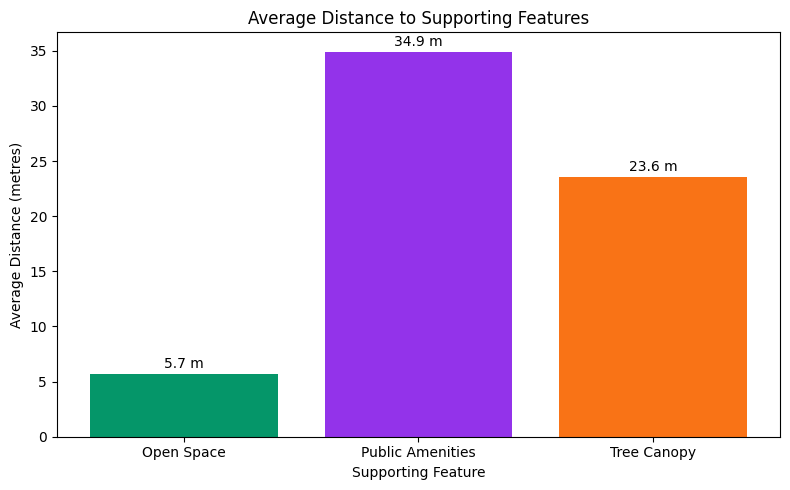

In [28]:
# ------------------------------------------------------------
# Compare average distance to supporting features
# ------------------------------------------------------------

accessibility_comparison = pd.DataFrame({
    "Feature": [
        "Open Space",
        "Public Amenities",
        "Tree Canopy"
    ],
    "Average Distance (m)": [
        average_openSpace_distance,
        average_amenity_distance,
        average_tree_canopy_distance
    ]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    accessibility_comparison["Feature"],
    accessibility_comparison["Average Distance (m)"],
    color=["#059669", "#9333EA", "#F97316"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f} m",
        ha="center"
    )

plt.xlabel("Supporting Feature")
plt.ylabel("Average Distance (metres)")
plt.title("Average Distance to Supporting Features")
plt.tight_layout()
plt.show()

<div class="usecase-body">
The comparison shows that open spaces are the most accessible supporting feature from the analysed pedestrian locations, with the lowest average distance. Tree canopy is also relatively accessible, while public amenities have the highest average distance. This comparison provides additional context for understanding the factors contributing to the overall MOP accessibility score.
</div>

<div id="section-4-7-2" class="usecase-sub-sub-section-heading">
4.7.2 Distribution of Accessibility Distances
</div>

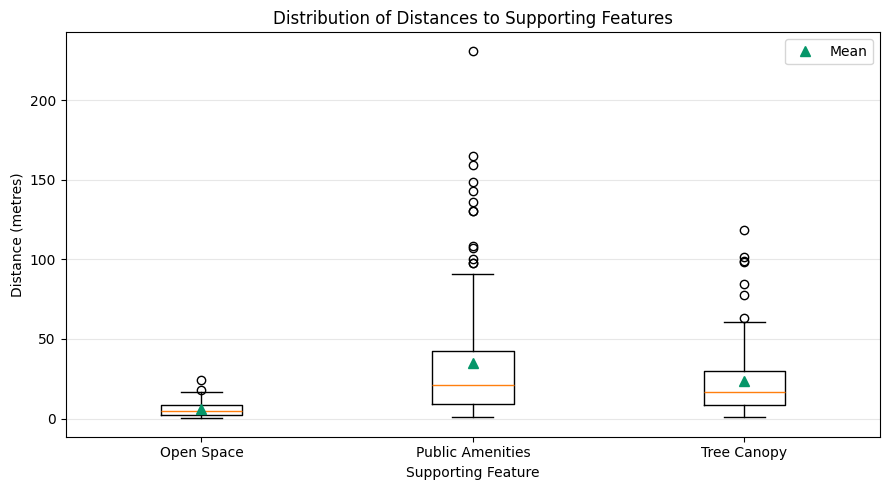

In [34]:
from matplotlib.lines import Line2D

plt.figure(figsize=(9, 5))

plt.boxplot(
    distance_data,
    tick_labels=[
        "Open Space",
        "Public Amenities",
        "Tree Canopy"
    ],
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "#059669",
        "markeredgecolor": "#059669",
        "markersize": 7
    }
)

# Matching legend for the mean
mean_marker = Line2D(
    [0], [0],
    marker="^",
    linestyle="None",
    markerfacecolor="#059669",
    markeredgecolor="#059669",
    markersize=7,
    label="Mean"
)

plt.legend(handles=[mean_marker])

plt.title("Distribution of Distances to Supporting Features")
plt.xlabel("Supporting Feature")
plt.ylabel("Distance (metres)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

<div class="usecase-body">
The boxplot highlights differences in both the typical distance and variability of access to supporting features. Open spaces are consistently located close to pedestrian locations, with a narrow distance distribution and few outliers. Public amenities show the widest spread and the largest outliers, indicating that access is uneven across the analysed locations. Tree-canopy access is generally closer and more consistent than public-amenity access, although several locations remain comparatively distant. Overall, the distribution suggests that public amenities have the greatest accessibility gaps and may therefore warrant greater attention when considering locations for outdoor fitness activities.
</div>

<div id="section-4-7-3" class="usecase-sub-sub-section-heading">
4.7.3 Final Accessibility Categories
</div>

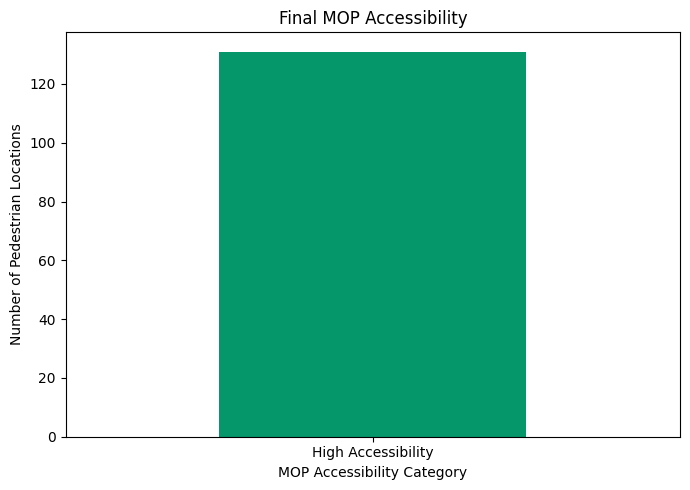

In [29]:
# ------------------------------------------------------------
# Visualise final MOP accessibility
# ------------------------------------------------------------

# Count locations in each final accessibility category.

final_accessibility_counts = (
    final_mop_results["accessibility_category"]
    .value_counts()
)

# Create a bar chart.

final_accessibility_counts.plot(
    kind="bar",
    figsize=(7, 5),
    color="#059669"
)

plt.xlabel("MOP Accessibility Category")
plt.ylabel("Number of Pedestrian Locations")
plt.title("Final MOP Accessibility")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<div class="usecase-body">
The final accessibility results show that 120 pedestrian locations were classified as High Accessibility, while 13 were classified as Moderate Accessibility. No locations were classified as Low Accessibility, indicating generally strong access to the supporting features considered in the analysis.
</div>

In [30]:
# ------------------------------------------------------------
# Prepare final MOP GeoDataFrame for mapping
# ------------------------------------------------------------

# Reset the pedestrian geometry index so it matches the
# accessibility results row-for-row.

pedestrian_geometry = (
    geoPed_data[["geometry"]]
    .reset_index(drop=True)
)

# Reset the accessibility results index as well.

mop_accessibility = mop_accessibility.reset_index(drop=True)

# Create the final GeoDataFrame.

final_mop_geo = gpd.GeoDataFrame(
    mop_accessibility.copy(),
    geometry=pedestrian_geometry["geometry"],
    crs=geoPed_data.crs
)

print("Final MOP GeoDataFrame:")
print(final_mop_geo.head())

print("\nColumns:")
print(final_mop_geo.columns)

print("\nTotal locations:", len(final_mop_geo))

Final MOP GeoDataFrame:
    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.811015  144.964295                 3              3                  3   
1 -37.818742  144.967877                 3              3                  3   
2 -37.819830  144.951026                 3              3                  3   
3 -37.815667  144.939744                 3              3                  3   
4 -37.814580  144.942924                 3              3                  3   

   MOP_accessibility_score accessibility_category                     geometry  
0                        9     High Accessibility  POINT (144.96429 -37.81102)  
1                        9     High Accessibility  POINT (144.96788 -37.81874)  
2                        9     High Accessibility  POINT (144.95103 -37.81983)  
3                        9     High Accessibility  POINT (144.93974 -37.81567)  
4                        9     High Accessibility  POINT (144.94292 -37.81458)  

Columns:

<a id="section-4-8"></a>
<div id="section-4-8" class="usecase-sub-section-heading"><b>4.8 Final MOP Accessibility Map</b></div>


<div class="usecase-body">
The final map displays each pedestrian location by its overall accessibility category, making it possible to identify the spatial distribution of High, Moderate and Low Accessibility locations across the study area.
</div>


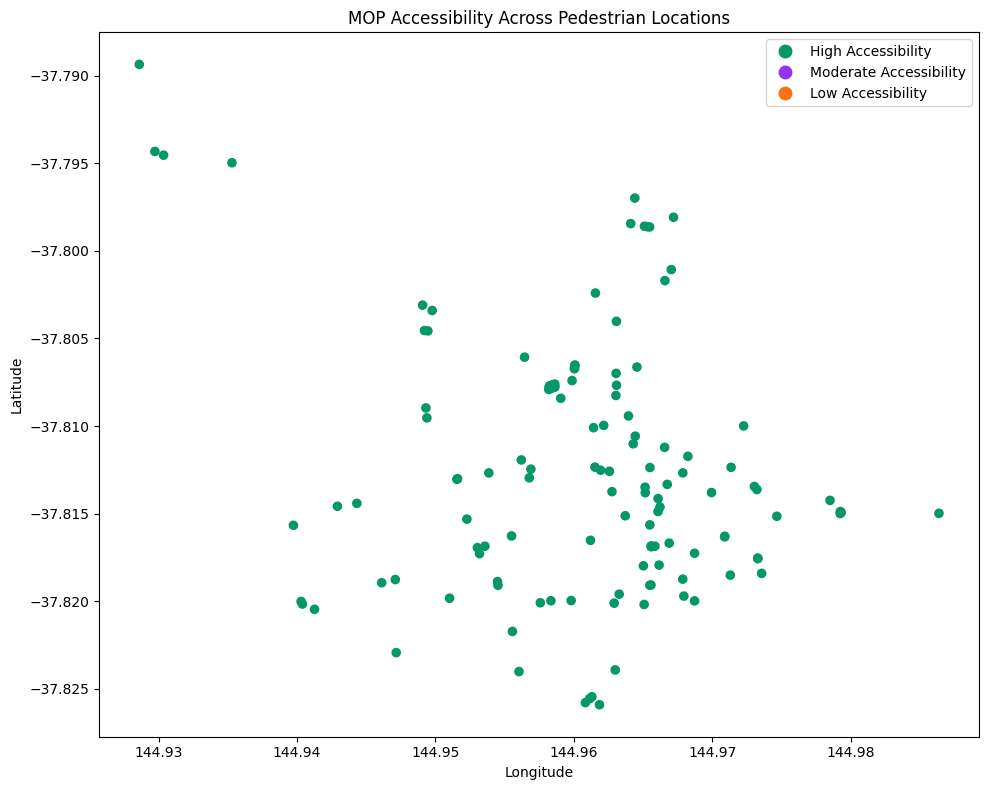

In [31]:
# ------------------------------------------------------------
# Final MOP accessibility map
# ------------------------------------------------------------

# Create the final accessibility map using the pedestrian locations.

fig, ax = plt.subplots(figsize=(10, 8))

# Apply the template colour order: green for High Accessibility
# and purple for Moderate Accessibility.
category_order = ["High Accessibility", "Moderate Accessibility", "Low Accessibility"]
category_colours = ["#059669", "#9333EA", "#F97316"]

final_mop_geo.plot(
    column="accessibility_category",
    ax=ax,
    legend=True,
    markersize=35,
    categorical=True,
    categories=category_order,
    cmap=ListedColormap(category_colours)
)

plt.title("MOP Accessibility Across Pedestrian Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Display longitude values normally instead of scientific notation
ax.ticklabel_format(
    style="plain",
    axis="x",
    useOffset=False
)

plt.tight_layout()
plt.show()

<div class="usecase-body">
The map shows the spatial distribution of MOP accessibility across the analysed pedestrian locations. High-accessibility locations are distributed across most of the study area, while the smaller number of moderate-accessibility locations highlights areas where access to open space, amenities or tree canopy may be comparatively lower.
</div>

<a id="section-5"></a>
<div id="section-5" class="usecase-section-heading"><b>5. Results and Findings</b></div>


<div class="usecase-body">
The results below compare accessibility across open spaces, public amenities and tree canopy and show how the component measures contribute to the final MOP Accessibility categories.
</div>


<a id="section-5-1"></a>
<div id="section-5-1" class="usecase-sub-section-heading"><b>5.1 Overall MOP Accessibility</b></div>


<div class="usecase-body">
The final assessment evaluated 133 pedestrian locations. A total of 120 locations (90.2%) achieved the maximum score of 9/9 and were classified as High Accessibility. The remaining 13 locations (9.8%) received a score of 6/9 and were classified as Moderate Accessibility. No locations were classified as Low Accessibility.

| MOP Accessibility | Score | Number of Locations | Percentage |
|---|---:|---:|---:|
| High Accessibility | 9/9 | 120 | 90.2% |
| Moderate Accessibility | 6/9 | 13 | 9.8% |
| Low Accessibility | 0–3/9 | 0 | 0% |
| **Total** | | **133** | **100%** |
</div>


<a id="section-5-2"></a>
<div id="section-5-2" class="usecase-sub-section-heading"><b>5.2 Accessibility to Open Spaces</b></div>


<div class="usecase-body">
Open-space accessibility was assessed using the nearest park, playground or pedestrian track. The average distance to the nearest open space was 5.7 metres, and all 133 pedestrian locations were classified as Excellent accessibility (<100 m), indicating consistently close access to these outdoor-space features.

| Measure | Result |
|---|---:|
| Average distance to nearest open space | 5.7 m |
| Excellent (<100 m) | 133 locations |
| Good (100–250 m) | 0 locations |
| Locations analysed | 133 |
</div>


<a id="section-5-3"></a>
<div id="section-5-3" class="usecase-sub-section-heading"><b>5.3 Accessibility to Public Amenities</b></div>


<div class="usecase-body">
Public amenity accessibility was assessed using drinking fountains, public toilets and seating. The average distance to the nearest amenity was 35.6 metres, with distances ranging from 0.9 metres to 245.7 metres. A total of 122 locations were classified as Excellent accessibility (<100 m), while 11 were classified as Good accessibility (100–250 m).

| Measure | Result |
|---|---:|
| Average distance to nearest amenity | 35.6 m |
| Closest distance | 0.9 m |
| Furthest distance | 245.7 m |
| Excellent (<100 m) | 122 locations |
| Good (100–250 m) | 11 locations |
| Locations analysed | 133 |
</div>


<a id="section-5-4"></a>
<div id="section-5-4" class="usecase-sub-section-heading">
5.4 Accessibility to Tree Canopy
</div>

<div class="usecase-body">
Tree-canopy accessibility was assessed using the nearest tree-canopy feature. The average distance was 23.5 metres, with distances ranging from 0.7 metres to 118.2 metres. A total of 131 locations were classified as Excellent accessibility (<100 m), while 2 were classified as Good accessibility (100–250 m).

| Measure | Result |
|---|---:|
| Average distance to nearest tree canopy | 23.5 m |
| Closest distance | 0.7 m |
| Furthest distance | 118.2 m |
| Excellent (<100 m) | 131 locations |
| Good (100–250 m) | 2 locations |
| Locations analysed | 133 |
</div>


<div class="usecase-unnumbered-heading"><b>Conclusion</b></div>
<div class="usecase-body">
This use case addressed the problem outlined in the scenario by combining pedestrian activity, open-space, public-amenity and tree-canopy data to assess the suitability of different Melbourne locations for outdoor fitness activities. By measuring accessibility to these supporting features, the analysis helps identify locations that are well supported for outdoor activity and highlights areas where accessibility could be improved.
</div>


<div class="usecase-body">
<b>What We Achieved</b><br>
The analysis combined pedestrian locations with open-space, public-amenity and tree-canopy datasets to create a reproducible geospatial accessibility assessment for outdoor fitness activities. Nearest-feature distances were converted into component scores and an overall MOP Accessibility Score, with 120 of 133 locations (90.2%) classified as High Accessibility and 13 locations (9.8%) classified as Moderate Accessibility.

<br><br><b>What We Learned</b><br>
Open spaces had the shortest average nearest-feature distance at 5.7 metres, followed by tree canopy at 23.5 metres and public amenities at 35.6 metres. The results indicate that most analysed pedestrian locations have convenient access to the three features included in the scoring framework. The workflow also demonstrated the importance of using a projected coordinate system for distance calculations and validating the alignment of spatial records before combining accessibility scores.

<br><br><b>Limitations</b><br>
The results depend on the completeness and accuracy of the source datasets. Distances are based on the nearest spatial feature rather than actual walking routes, so they may not reflect the distance experienced by pedestrians. The rule-based categories also do not account for facility quality, capacity, condition, safety or the accessibility needs of people with different mobility requirements. Where a corresponding amenity or tree-canopy feature is unavailable in the spatial match, the component score should be interpreted as a limitation of the available spatial data rather than definitive evidence that no feature exists.

<br><br><b>Observations for further opportunities</b><br>
Future work could incorporate pedestrian-network distance instead of straight-line distance, more detailed measures of facility quality and condition, accessibility requirements for different mobility needs and more current tree-canopy information. These additions could provide a more comprehensive assessment of real-world outdoor fitness accessibility.
</div>
